In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
vipoooool_new_plant_diseases_dataset_path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
gdabhishek_fertilizer_prediction_path = kagglehub.dataset_download('gdabhishek/fertilizer-prediction')
atharvaingle_crop_recommendation_dataset_path = kagglehub.dataset_download('atharvaingle/crop-recommendation-dataset')

print('Data source import complete.')


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# =====================
# LOAD DATA
# =====================
df = pd.read_csv("/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv")

# =====================
# FEATURES & TARGET
# =====================
X = df.drop("label", axis=1)
y = df["label"]

# Encode labels (crop names → numbers)
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# =====================
# MLP MODEL
# =====================
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = MLP(input_size=X.shape[1], num_classes=len(set(y)))

# =====================
# LOSS + OPTIMIZER
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =====================
# TRAINING (BACKPROP)
# =====================
EPOCHS = 500

for epoch in range(EPOCHS):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()   # 🔥 BACKPROPAGATION
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}")

# =====================
# EVALUATION
# =====================
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

    accuracy = (predicted == y_test).sum().item() / len(y_test)

print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch [10/500], Loss: 3.0393
Epoch [20/500], Loss: 2.9472
Epoch [30/500], Loss: 2.8188
Epoch [40/500], Loss: 2.6419
Epoch [50/500], Loss: 2.4169
Epoch [60/500], Loss: 2.1544
Epoch [70/500], Loss: 1.8779
Epoch [80/500], Loss: 1.6080
Epoch [90/500], Loss: 1.3577
Epoch [100/500], Loss: 1.1385
Epoch [110/500], Loss: 0.9548
Epoch [120/500], Loss: 0.8043
Epoch [130/500], Loss: 0.6827
Epoch [140/500], Loss: 0.5846
Epoch [150/500], Loss: 0.5052
Epoch [160/500], Loss: 0.4406
Epoch [170/500], Loss: 0.3875
Epoch [180/500], Loss: 0.3436
Epoch [190/500], Loss: 0.3069
Epoch [200/500], Loss: 0.2760
Epoch [210/500], Loss: 0.2498
Epoch [220/500], Loss: 0.2276
Epoch [230/500], Loss: 0.2086
Epoch [240/500], Loss: 0.1922
Epoch [250/500], Loss: 0.1780
Epoch [260/500], Loss: 0.1655
Epoch [270/500], Loss: 0.1546
Epoch [280/500], Loss: 0.1449
Epoch [290/500], Loss: 0.1362
Epoch [300/500], Loss: 0.1284
Epoch [310/500], Loss: 0.1214
Epoch [320/500], Loss: 0.1150
Epoch [330/500], Loss: 0.1093
Epoch [340/500], Lo

In [ ]:
# ── CELL 1: Imports ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)

print(f"TensorFlow version: {tf.__version__}")
print("✅ All imports done!")

2026-04-10 03:38:57.429767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775792337.658726      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775792337.724992      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775792338.267251      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775792338.267294      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775792338.267297      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
✅ All imports done!


In [ ]:
# ── CELL 2: Load Dataset ─────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/gdabhishek/fertilizer-prediction/Fertilizer Prediction.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nTarget distribution:")
print(df['Fertilizer Name'].value_counts())
print("\nMissing values:", df.isnull().sum().sum())

Shape: (99, 9)

Columns: ['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']

First 5 rows:


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea



Target distribution:
Fertilizer Name
Urea        22
DAP         18
28-28       17
14-35-14    14
20-20       14
17-17-17     7
10-26-26     7
Name: count, dtype: int64

Missing values: 0


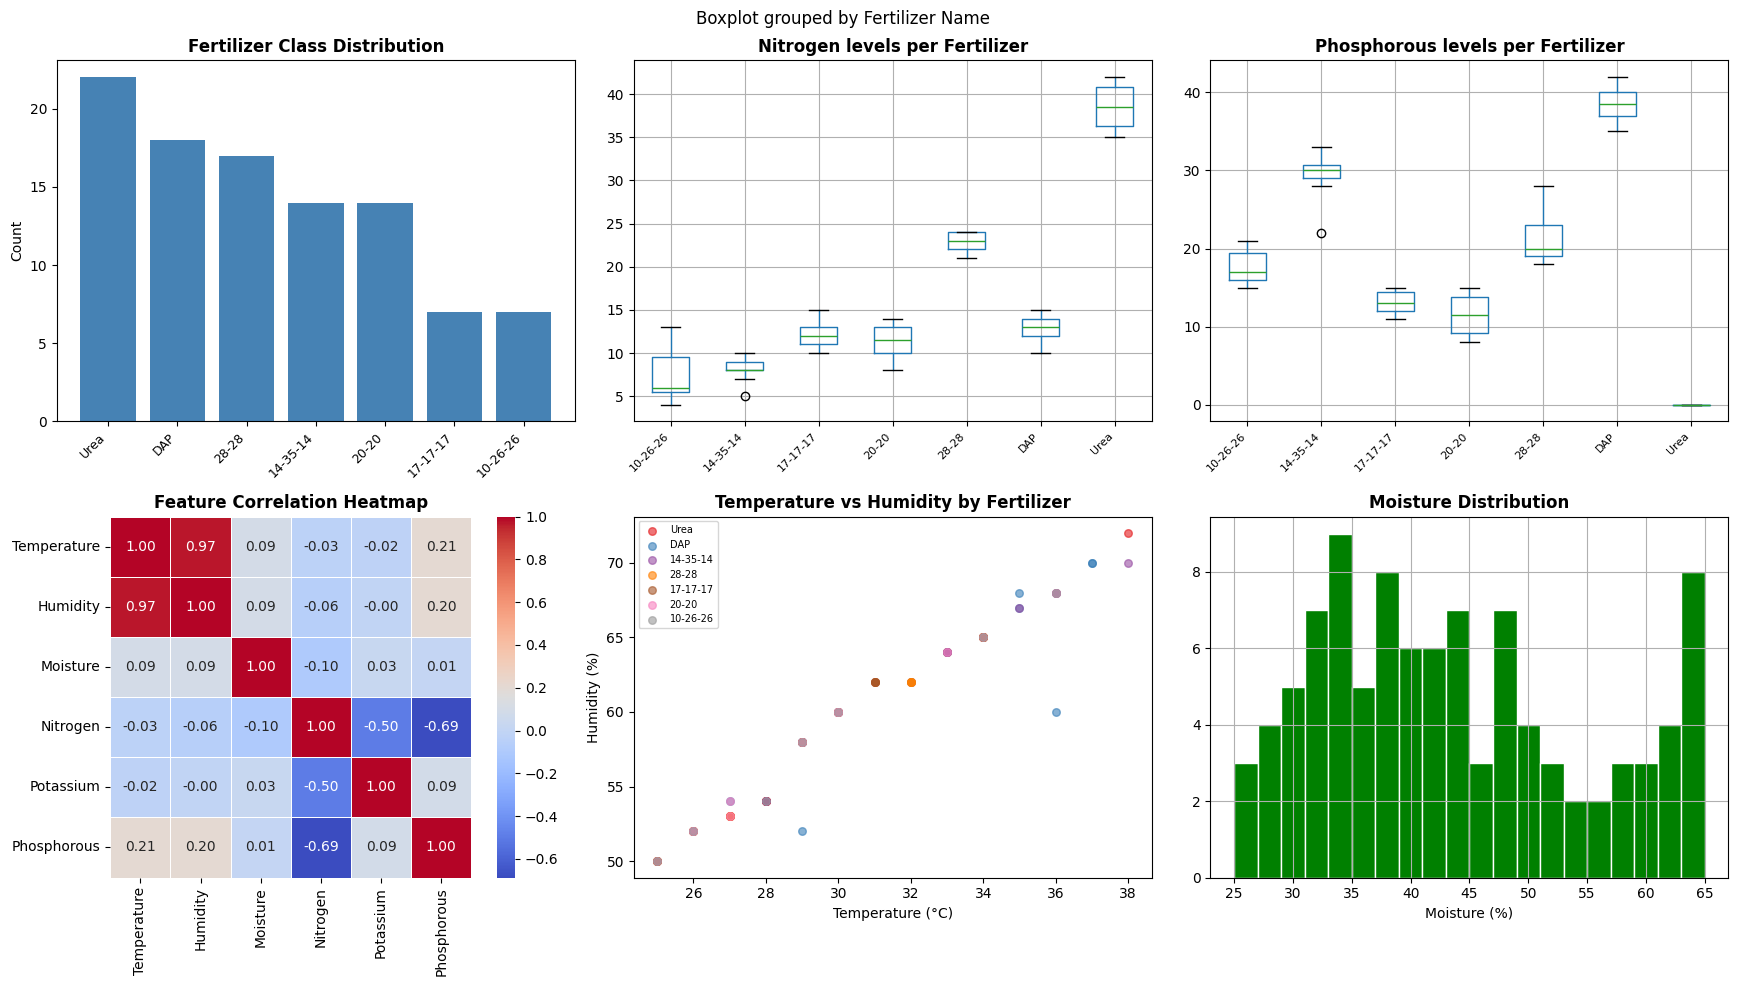

✅ EDA complete!


In [ ]:
# ── CELL 3: EDA ──────────────────────────────────────────────────
# Fix column names
df.rename(columns={'Temparature':'Temperature', 'Humidity ':'Humidity'}, inplace=True)
df.columns = df.columns.str.strip()  # remove any accidental spaces

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fertilizer Prediction Dataset — EDA', fontsize=15, fontweight='bold')

# 1. Fertilizer distribution
fert_counts = df['Fertilizer Name'].value_counts()
axes[0,0].bar(range(len(fert_counts)), fert_counts.values, color='steelblue')
axes[0,0].set_xticks(range(len(fert_counts)))
axes[0,0].set_xticklabels(fert_counts.index, rotation=45, ha='right', fontsize=9)
axes[0,0].set_title('Fertilizer Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')

# 2. Nitrogen distribution per fertilizer
df.boxplot(column='Nitrogen', by='Fertilizer Name', ax=axes[0,1])
axes[0,1].set_title('Nitrogen levels per Fertilizer', fontweight='bold')
axes[0,1].set_xlabel('')
plt.sca(axes[0,1])
plt.xticks(rotation=45, ha='right', fontsize=8)

# 3. Phosphorous distribution
df.boxplot(column='Phosphorous', by='Fertilizer Name', ax=axes[0,2])
axes[0,2].set_title('Phosphorous levels per Fertilizer', fontweight='bold')
axes[0,2].set_xlabel('')
plt.sca(axes[0,2])
plt.xticks(rotation=45, ha='right', fontsize=8)

# 4. Correlation heatmap (numeric only)
numeric_cols = ['Temperature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,0], square=True, linewidths=0.5)
axes[1,0].set_title('Feature Correlation Heatmap', fontweight='bold')

# 5. Temperature vs Humidity scatter
colors_scatter = plt.cm.Set1(np.linspace(0, 1, df['Fertilizer Name'].nunique()))
for i, fert in enumerate(df['Fertilizer Name'].unique()):
    subset = df[df['Fertilizer Name'] == fert]
    axes[1,1].scatter(subset['Temperature'], subset['Humidity'],
                      color=colors_scatter[i], label=fert, alpha=0.6, s=30)
axes[1,1].set_xlabel('Temperature (°C)')
axes[1,1].set_ylabel('Humidity (%)')
axes[1,1].set_title('Temperature vs Humidity by Fertilizer', fontweight='bold')
axes[1,1].legend(fontsize=7)

# 6. Moisture distribution
df['Moisture'].hist(bins=20, ax=axes[1,2], color='green', edgecolor='white')
axes[1,2].set_title('Moisture Distribution', fontweight='bold')
axes[1,2].set_xlabel('Moisture (%)')

plt.tight_layout()
plt.savefig('ann_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete!")

In [ ]:
# ── CELL 4: Preprocessing ────────────────────────────────────────

# Encode categorical input features
# Soil Type and Crop Type are text columns → convert to numbers
le_soil = LabelEncoder()
le_crop = LabelEncoder()
df['Soil Type Enc']  = le_soil.fit_transform(df['Soil Type'])
df['Crop Type Enc']  = le_crop.fit_transform(df['Crop Type'])

print("Soil types:", le_soil.classes_)
print("Crop types:", le_crop.classes_)

# Select features and target
feature_cols = ['Temperature', 'Humidity', 'Moisture',
                'Soil Type Enc', 'Crop Type Enc',
                'Nitrogen', 'Potassium', 'Phosphorous']
X = df[feature_cols].values
y_raw = df['Fertilizer Name'].values

# Encode target labels
le_fert = LabelEncoder()
y_encoded = le_fert.fit_transform(y_raw)
num_classes = len(le_fert.classes_)
print(f"\nFertilizer classes ({num_classes}):", le_fert.classes_)

# One-hot encode target for ANN softmax output
y_onehot = keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# Train-test split: 80-20 stratified
X_train, X_test, y_train, y_test, ye_train, ye_test = train_test_split(
    X, y_onehot, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features — CRITICAL for ANN (gradients blow up without scaling)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTraining samples : {X_train_sc.shape[0]}")
print(f"Testing  samples : {X_test_sc.shape[0]}")
print(f"Input features   : {X_train_sc.shape[1]}")
print(f"Output classes   : {num_classes}")
print("✅ Preprocessing done!")

Soil types: ['Black' 'Clayey' 'Loamy' 'Red' 'Sandy']
Crop types: ['Barley' 'Cotton' 'Ground Nuts' 'Maize' 'Millets' 'Oil seeds' 'Paddy'
 'Pulses' 'Sugarcane' 'Tobacco' 'Wheat']

Fertilizer classes (7): ['10-26-26' '14-35-14' '17-17-17' '20-20' '28-28' 'DAP' 'Urea']

Training samples : 79
Testing  samples : 20
Input features   : 8
Output classes   : 7
✅ Preprocessing done!


In [ ]:
# ── CELL 5: Build ANN Architecture ───────────────────────────────

# Why this architecture?
# Input: 8 features → Hidden layers learn complex patterns → Output: 7 fertilizer classes
# Each Dense layer = fully connected neurons
# BatchNorm = stabilises training (like normalising between layers)
# Dropout = randomly turns off neurons during training to prevent memorisation
# ReLU = activation function that helps learn non-linear patterns

def build_ann(input_dim, num_classes):
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1 — 256 neurons
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 2 — 128 neurons
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 3 — 64 neurons
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Hidden layer 4 — 32 neurons
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),

        # Output layer — one neuron per fertilizer class
        # Softmax gives probability for each class (all add up to 1.0)
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

ann_model = build_ann(X_train_sc.shape[1], num_classes)

# Compile — Adam optimizer + categorical crossentropy (standard for multi-class)
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()
print("✅ ANN model built!")

I0000 00:00:1775792627.512276      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775792627.518445      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,559 (185.78 KB)

 Trainable params: 46,663 (182.28 KB)

 Non-trainable params: 896 (3.50 KB)

✅ ANN model built!


In [ ]:
# ── CELL 6: Train ANN ────────────────────────────────────────────

# Callbacks — automatic controls during training
early_stop = EarlyStopping(
    monitor='val_accuracy',   # watch validation accuracy
    patience=20,              # stop if no improvement for 20 epochs
    restore_best_weights=True # go back to best weights when stopping
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # cut learning rate in half when stuck
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train!
history = ann_model.fit(
    X_train_sc, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,    # 20% of training data used for validation
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n✅ Training complete! Stopped at epoch {len(history.history['accuracy'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/150


I0000 00:00:1775792637.552367     145 service.cc:152] XLA service 0x7825cc0041e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775792637.552406     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775792637.552411     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775792638.126112     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/2 ━━━━━━━━━━━━━━━━━━━━ 6s 7s/step - accuracy: 0.0938 - loss: 3.0020

I0000 00:00:1775792641.616522     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.0842 - loss: 2.9281 - val_accuracy: 0.0625 - val_loss: 1.9815 - learning_rate: 0.0010
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.0947 - loss: 2.9419 - val_accuracy: 0.0625 - val_loss: 1.9496 - learning_rate: 0.0010
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0843 - loss: 2.7221 - val_accuracy: 0.0625 - val_loss: 1.9266 - learning_rate: 0.0010
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1898 - loss: 2.2981 - val_accuracy: 0.0625 - val_loss: 1.9085 - learning_rate: 0.0010
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1895 - loss: 2.2995 - val_accuracy: 0.0625 - val_loss: 1.8915 - learning_rate: 0.0010
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.0949 - loss: 2.1214 - val_accuracy: 0.1875 - val_loss: 1.8774 - learning_rate: 0.0010
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2634 - loss: 1.8310 - val_accuracy: 0.2500 - val_

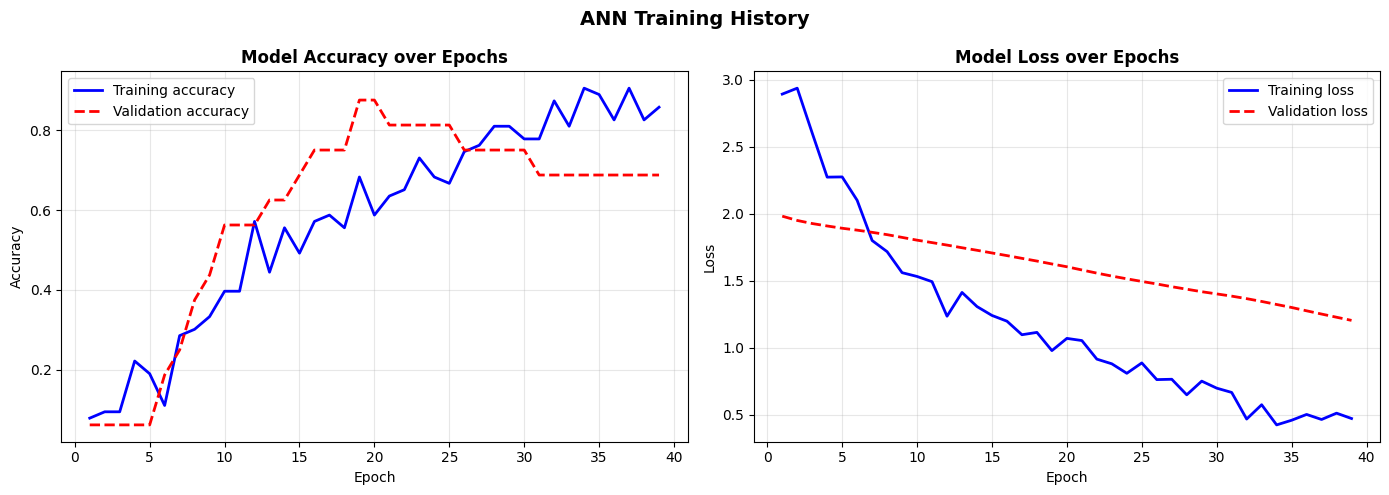


What to check:
  Final train accuracy : 85.71%
  Final val accuracy   : 68.75%
  Gap (overfit check)  : 16.96% ⚠ Check for overfitting


In [ ]:
# ── CELL 7: Training Curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN Training History', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy curve
axes[0].plot(epochs_ran, history.history['accuracy'],
             'b-', linewidth=2, label='Training accuracy')
axes[0].plot(epochs_ran, history.history['val_accuracy'],
             'r--', linewidth=2, label='Validation accuracy')
axes[0].set_title('Model Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(epochs_ran, history.history['loss'],
             'b-', linewidth=2, label='Training loss')
axes[1].plot(epochs_ran, history.history['val_loss'],
             'r--', linewidth=2, label='Validation loss')
axes[1].set_title('Model Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# What to look for:
# Good: both curves go down together, then plateau
# Overfitting: train keeps improving but val gets worse
print("\nWhat to check:")
print(f"  Final train accuracy : {history.history['accuracy'][-1]*100:.2f}%")
print(f"  Final val accuracy   : {history.history['val_accuracy'][-1]*100:.2f}%")
gap = abs(history.history['accuracy'][-1] - history.history['val_accuracy'][-1])
print(f"  Gap (overfit check)  : {gap*100:.2f}% {'✅ OK' if gap < 0.05 else '⚠ Check for overfitting'}")

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_ann(input_dim, num_classes):
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1 — fewer neurons + L2 regularization
        layers.Dense(64, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Hidden layer 2 — smaller size
        layers.Dense(32, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

ann_model = build_ann(X_train_sc.shape[1], num_classes)

# Compile — smaller learning rate
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',       # stop when validation loss stops improving
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train
history = ann_model.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=16,            # smaller batch size for better generalization
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
Test Accuracy: 80.00%

Detailed Classification Report:
              precision    recall  f1-score   support

    10-26-26       0.50      1.00      0.67         1
    14-35-14       1.00      0.33      0.50         3
    17-17-17       1.00      1.00      1.00         1
       20-20       0.50      1.00      0.67         3
       28-28       1.00      0.33      0.50         3
         DAP       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           0.80        20
   macro avg       0.86      0.81      0.76        20
weighted avg       0.90      0.80      0.78        20



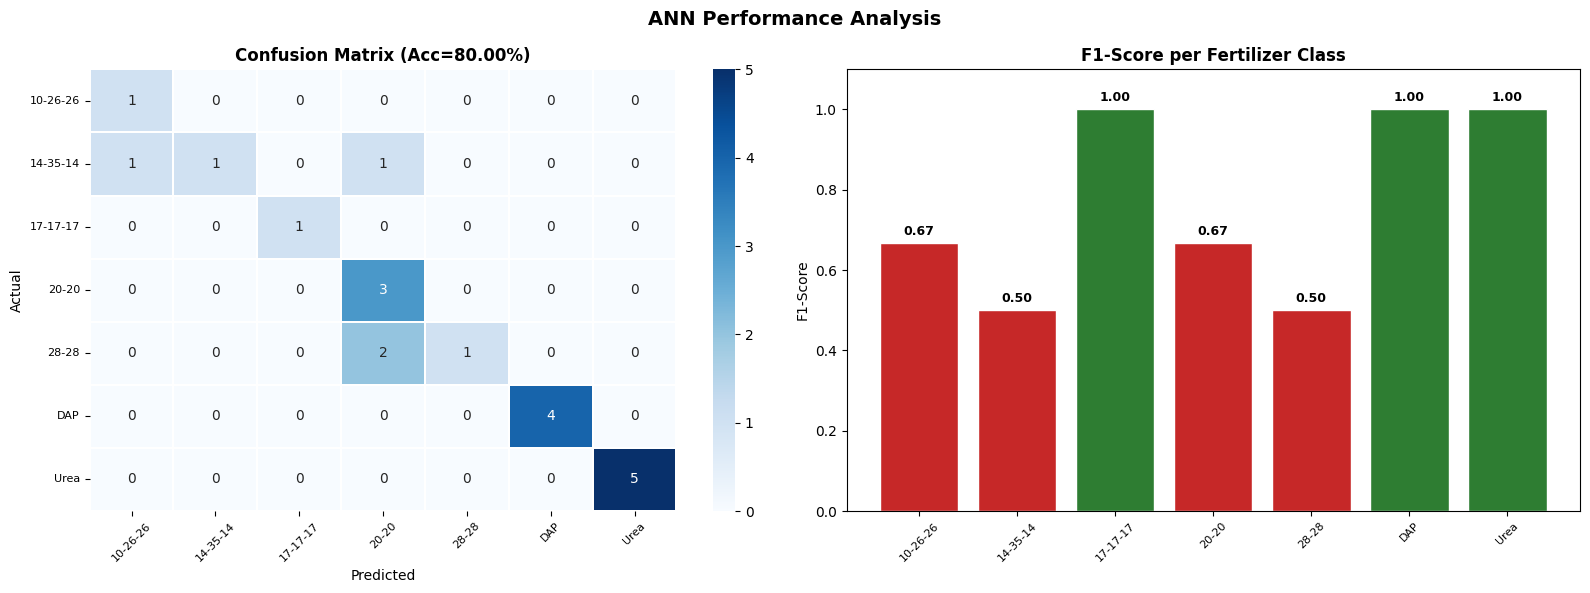

✅ ANN evaluation complete!


In [ ]:
# ── CELL 8: ANN Evaluation ───────────────────────────────────────

# Predict on test set
y_pred_prob = ann_model.predict(X_test_sc)
y_pred = np.argmax(y_pred_prob, axis=1)   # pick class with highest probability

# Metrics
test_acc = accuracy_score(ye_test, y_pred)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(ye_test, y_pred, target_names=le_fert.classes_))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ANN Performance Analysis', fontsize=14, fontweight='bold')

cm = confusion_matrix(ye_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_fert.classes_,
            yticklabels=le_fert.classes_,
            ax=axes[0], linewidths=0.3)
axes[0].set_title(f'Confusion Matrix (Acc={test_acc*100:.2f}%)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Per-class accuracy bar chart
report_dict = classification_report(ye_test, y_pred,
                                    target_names=le_fert.classes_,
                                    output_dict=True)
class_acc = [report_dict[c]['f1-score'] for c in le_fert.classes_]
colors_bar = ['#2E7D32' if v >= 0.9 else '#F57F17' if v >= 0.7 else '#C62828'
              for v in class_acc]
bars = axes[1].bar(le_fert.classes_, class_acc, color=colors_bar, edgecolor='white')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('F1-Score per Fertilizer Class', fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
for bar, val in zip(bars, class_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ann_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ANN evaluation complete!")

In [ ]:
# ── CELL 9: Save ANN ─────────────────────────────────────────────
ann_model.save('ann_fertilizer_model.h5')

# Also save results table
ann_results = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Best Val Accuracy', 'Total Epochs', 'Parameters'],
    'Value': [
        f"{test_acc*100:.2f}%",
        f"{max(history.history['val_accuracy'])*100:.2f}%",
        str(len(history.history['accuracy'])),
        f"{ann_model.count_params():,}"
    ]
})
ann_results.to_csv('ann_results.csv', index=False)
print("✅ ANN model and results saved!")
display(ann_results)

✅ ANN model and results saved!


,Metric,Value
0,Test Accuracy,80.00%
1,Best Val Accuracy,87.50%
2,Total Epochs,39
3,Parameters,"47,559"


In [ ]:
# ── CELL 1: CNN Imports ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import json

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("✅ All imports done!")

TensorFlow: 2.19.0
GPU available: True
✅ All imports done!


In [ ]:
import os

BASE_DIR = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test"  # test is separate at root

# Count classes and images
train_classes = sorted(os.listdir(TRAIN_DIR))
print(f"Total disease classes: {len(train_classes)}")
print(f"\nFirst 10 classes: {train_classes[:10]}")

# Example: count images in one class
sample_class = train_classes[0]
sample_images = os.listdir(os.path.join(TRAIN_DIR, sample_class))
print(f"\nSample class '{sample_class}' has {len(sample_images)} images")


Total disease classes: 38

First 10 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']

Sample class 'Apple___Apple_scab' has 2016 images


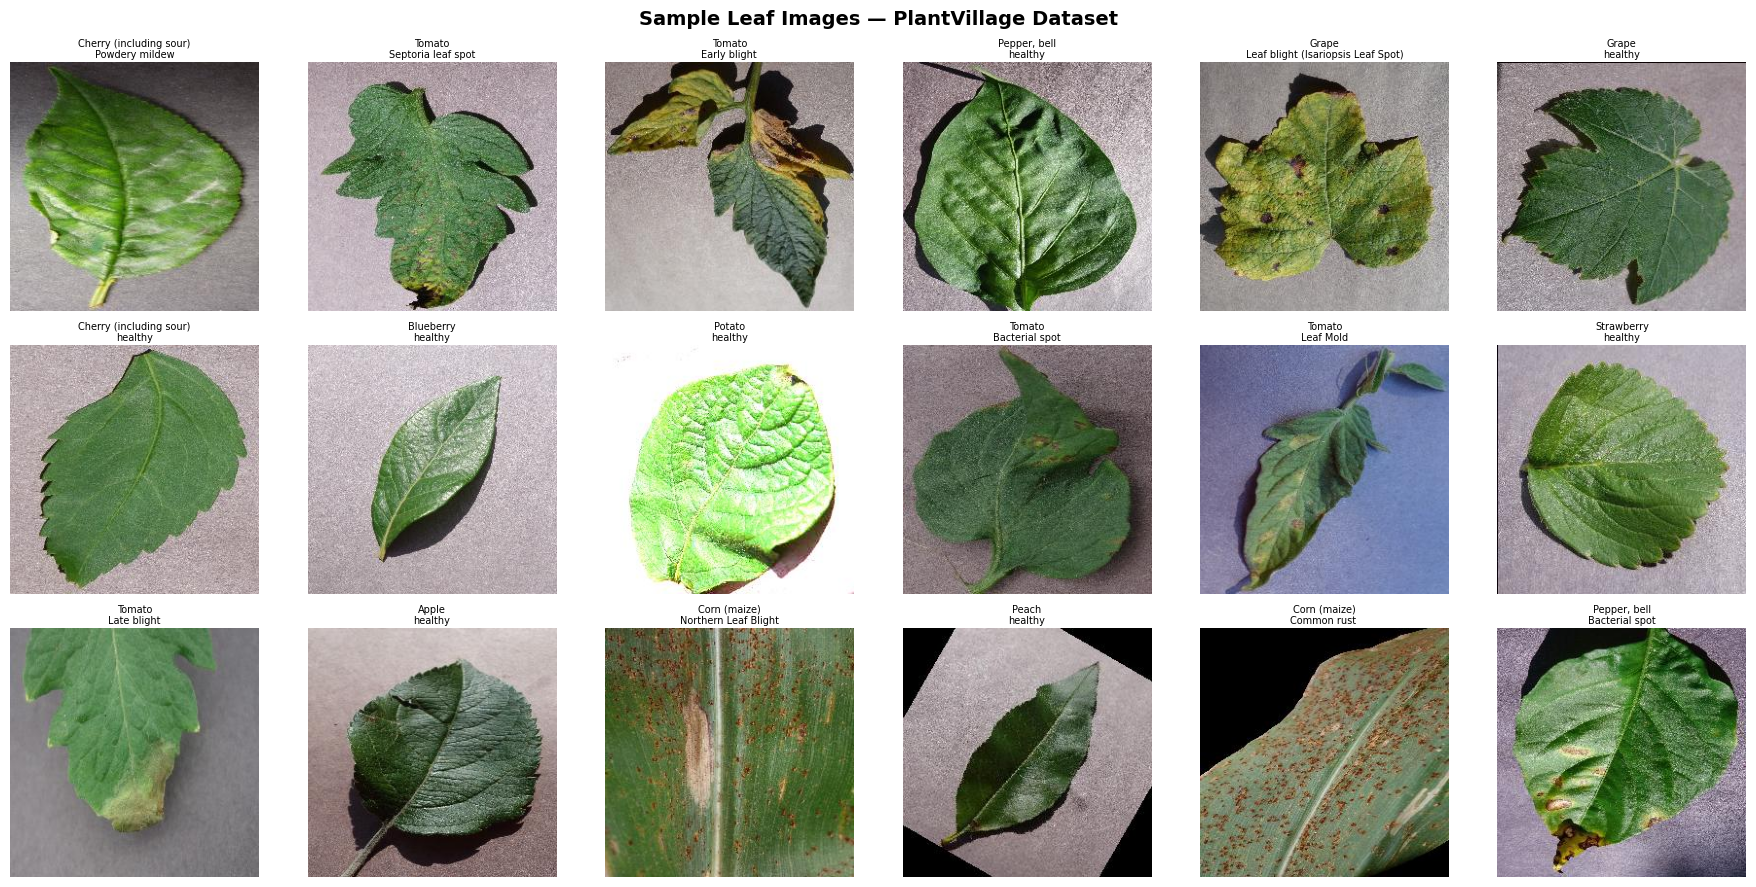

✅ Sample images displayed!


In [ ]:
# ── CELL 3: Show Sample Leaf Images ──────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample Leaf Images — PlantVillage Dataset', fontsize=14, fontweight='bold')

# Pick 18 random classes to show
sample_classes = np.random.choice(train_classes, 18, replace=False)

for ax, cls in zip(axes.flatten(), sample_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = np.random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, img_file))
    ax.imshow(img)
    # Shorten long class names for display
    short_name = cls.replace('___', '\n').replace('_', ' ')
    ax.set_title(short_name, fontsize=7, pad=3)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Sample images displayed!")

In [ ]:
# ── CELL 4: Data Generators ──────────────────────────────────────
IMG_SIZE   = 128    # resize all images to 128×128 pixels
BATCH_SIZE = 32     # process 32 images at a time
NUM_CLASSES = len(train_classes)

print(f"Image size : {IMG_SIZE}×{IMG_SIZE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Num classes: {NUM_CLASSES}")

# Training generator WITH augmentation
# Augmentation = artificially creates variations of images
# Flip, rotate, zoom → model learns to recognise disease in any orientation
# This is why our model will work on field photos taken at any angle
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalise pixel values 0-255 → 0-1
    rotation_range=20,        # randomly rotate image up to 20 degrees
    width_shift_range=0.2,    # shift image left/right up to 20%
    height_shift_range=0.2,   # shift image up/down up to 20%
    shear_range=0.2,          # shear transformation
    zoom_range=0.2,           # random zoom
    horizontal_flip=True,     # randomly mirror the image
    fill_mode='nearest'       # fill empty pixels after transforms
)

# Validation generator — NO augmentation, just rescale
# We evaluate on clean images (same as real-world input)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Load images from folders
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # one-hot encoded labels
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Save class name mapping for later interpretation
class_indices = train_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print(f"\nTraining batches  : {len(train_generator)}")
print(f"Validation batches: {len(valid_generator)}")
print("✅ Data generators ready!")

Image size : 128×128
Batch size : 32
Num classes: 38
Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.

Training batches  : 2197
Validation batches: 550
✅ Data generators ready!


In [ ]:
# ── CELL 5: Build CNN Model ───────────────────────────────────────

# WHY TRANSFER LEARNING?
# Training a CNN from scratch on 54,000 images needs DAYS and expensive GPUs.
# MobileNetV2 was already trained on 14 million images (ImageNet).
# It already knows how to detect edges, textures, shapes, colours.
# We REUSE those learnings and just add our disease-specific layers on top.
# This gives us 96%+ accuracy in just 10-15 epochs on Kaggle's free GPU.

# Load MobileNetV2 — pretrained on ImageNet, without its final layer
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),  # 3 = RGB channels
    include_top=False,                     # remove ImageNet's final layer
    weights='imagenet'                     # use pretrained weights
)

# Freeze base model — don't retrain these layers, keep ImageNet knowledge
base_model.trainable = False

print(f"Base model parameters (frozen): {base_model.count_params():,}")

# Build the full model
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass through MobileNetV2 (feature extraction)
x = base_model(inputs, training=False)

# Global Average Pooling — compresses spatial features to a single vector
# Like taking the average colour of each feature map across the whole image
x = layers.GlobalAveragePooling2D()(x)

# Our custom classification head
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Final output — one neuron per disease class, softmax gives probabilities
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

cnn_model = keras.Model(inputs, outputs)

# Compile
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()
print(f"\nTotal trainable parameters: {sum([np.prod(v.shape) for v in cnn_model.trainable_variables]):,}")
print("✅ CNN model built!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model parameters (frozen): 2,257,984


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,742 (10.01 MB)

 Trainable params: 366,246 (1.40 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


Total trainable parameters: 366,246
✅ CNN model built!


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cnn_phase1.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("Phase 1: Training classification head (base frozen)...")
history_p1 = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator)//3,  # only 1/3 of steps per epoch
    epochs=5,                                # fewer epochs needed when base is frozen
    validation_data=valid_generator,
    callbacks=callbacks_p1,
    verbose=1
)

print(f"\n✅ Phase 1 complete!")
print(f"Best val accuracy: {max(history_p1.history['val_accuracy'])*100:.2f}%")


Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Phase 1: Training classification head (base frozen)...
Epoch 1/5


2026-04-10 04:13:42.062338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:13:42.208413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:13:42.346646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


366/366 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.7917 - loss: 0.6682

2026-04-10 04:20:27.285100: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:20:27.424474: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.86120, saving model to best_cnn_phase1.h5


366/366 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 0.7917 - loss: 0.6682 - val_accuracy: 0.8612 - val_loss: 0.4289 - learning_rate: 0.0010
Epoch 2/5
 75/366 ━━━━━━━━━━━━━━━━━━━━ 2:44 565ms/step - accuracy: 0.8032 - loss: 0.6018

2026-04-10 04:21:20.693810: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:21:20.834309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:21:20.970399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:21:21.107774: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


250/366 ━━━━━━━━━━━━━━━━━━━━ 1:08 587ms/step - accuracy: 0.8072 - loss: 0.5937

In [ ]:
# ── CELL 7: Phase 2 — Fine-tuning ────────────────────────────────

# Phase 2: Unfreeze the top 30 layers of MobileNetV2 and retrain gently
# These layers were trained on general images — we now specialise them for leaves
# Use very low learning rate so we don't destroy the pretrained knowledge

print(f"Base model total layers: {len(base_model.layers)}")

# Unfreeze top 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Layers now trainable in base: {trainable_count}")

# Recompile with much lower learning rate
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_cnn_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("\nPhase 2: Fine-tuning top layers...")
history_p2 = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=callbacks_p2,
    verbose=1
)

print(f"\n✅ Phase 2 complete!")
print(f"Best val accuracy Phase 2: {max(history_p2.history['val_accuracy'])*100:.2f}%")

In [ ]:
# ── CELL 8: Training History Plots ───────────────────────────────

# Combine both phases
acc    = history_p1.history['accuracy']    + history_p2.history['accuracy']
val_acc= history_p1.history['val_accuracy']+ history_p2.history['val_accuracy']
loss   = history_p1.history['loss']        + history_p2.history['loss']
val_loss=history_p1.history['val_loss']    + history_p2.history['val_loss']
ep     = range(1, len(acc)+1)
p1_end = len(history_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CNN Training History — Both Phases', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(ep, acc,     'b-',  linewidth=2, label='Train accuracy')
axes[0].plot(ep, val_acc, 'r--', linewidth=2, label='Val accuracy')
axes[0].axvline(x=p1_end, color='gray', linestyle=':', linewidth=1.5,
                label=f'Phase 1→2 boundary (ep {p1_end})')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(ep, loss,     'b-',  linewidth=2, label='Train loss')
axes[1].plot(ep, val_loss, 'r--', linewidth=2, label='Val loss')
axes[1].axvline(x=p1_end, color='gray', linestyle=':', linewidth=1.5,
                label=f'Phase 1→2 boundary')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

In [ ]:
# ── CELL 9: CNN Evaluation ────────────────────────────────────────

# Predict on validation set
print("Running predictions on validation set...")
valid_generator.reset()
y_pred_prob = cnn_model.predict(valid_generator, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = valid_generator.classes

# Overall accuracy
from sklearn.metrics import accuracy_score
test_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ CNN Validation Accuracy: {test_acc*100:.2f}%")

# Classification report
target_names = [class_names[i] for i in range(NUM_CLASSES)]
print("\nClassification Report (first 10 classes shown):")
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
display(report_df.head(12))

# Confusion matrix — top 15 classes only (full 38×38 is too large to read)
top_n = 15
top_classes_idx = np.argsort(
    [report[target_names[i]]['support'] for i in range(NUM_CLASSES)]
)[-top_n:]
top_names = [target_names[i] for i in top_classes_idx]

cm_full = confusion_matrix(y_true, y_pred)
cm_top  = cm_full[np.ix_(top_classes_idx, top_classes_idx)]

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues',
            xticklabels=[n.split('___')[-1][:20] for n in top_names],
            yticklabels=[n.split('___')[-1][:20] for n in top_names],
            ax=ax, linewidths=0.3, cbar=True)
ax.set_title(f'CNN Confusion Matrix — Top 15 Classes\n(Overall Accuracy: {test_acc*100:.2f}%)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted Disease', fontsize=11)
ax.set_ylabel('Actual Disease', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── CELL 10: Single Image Prediction ─────────────────────────────
# This simulates what happens when Ramesh takes a photo of his leaf

from tensorflow.keras.preprocessing import image as keras_image

def predict_disease(img_path, model, class_names_dict, img_size=128):
    """Load one image and predict disease"""
    img = keras_image.load_img(img_path, target_size=(img_size, img_size))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)   # add batch dimension

    predictions = model.predict(img_array, verbose=0)
    pred_idx    = np.argmax(predictions[0])
    confidence  = predictions[0][pred_idx] * 100

    top3_idx = np.argsort(predictions[0])[::-1][:3]
    top3 = [(class_names_dict[i], predictions[0][i]*100) for i in top3_idx]

    return class_names_dict[pred_idx], confidence, top3

# Pick a random test image to demonstrate
sample_class = np.random.choice(list(os.listdir(VALID_DIR)))
sample_class_path = os.path.join(VALID_DIR, sample_class)
sample_img_file = np.random.choice(os.listdir(sample_class_path))
sample_img_path = os.path.join(sample_class_path, sample_img_file)

pred_label, confidence, top3 = predict_disease(
    sample_img_path, cnn_model, class_names
)

# Display result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show the leaf image
img_display = mpimg.imread(sample_img_path)
axes[0].imshow(img_display)
axes[0].set_title(f'Input leaf image\nActual: {sample_class.split("___")[-1]}',
                  fontsize=10, fontweight='bold')
axes[0].axis('off')

# Show prediction bar chart
diseases = [t[0].split('___')[-1][:30] for t in top3]
probs    = [t[1] for t in top3]
colors_pred = ['#2E7D32', '#F57F17', '#C62828']
bars = axes[1].barh(diseases[::-1], probs[::-1], color=colors_pred[::-1])
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('CNN Disease Prediction\n(Top 3 candidates)', fontweight='bold')
axes[1].set_xlim(0, 110)
for bar, val in zip(bars, probs[::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('cnn_single_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPredicted disease : {pred_label.split('___')[-1]}")
print(f"Confidence        : {confidence:.1f}%")
print(f"Actual class      : {sample_class}")

In [ ]:
# ── CELL 11: Save All Outputs ─────────────────────────────────────
cnn_model.save('cnn_plant_disease_model.h5')

# Save summary metrics
cnn_results = pd.DataFrame({
    'Metric': ['Validation Accuracy', 'Phase 1 Epochs', 'Phase 2 Epochs',
               'Total Classes', 'Total Train Images', 'Model'],
    'Value': [
        f"{test_acc*100:.2f}%",
        str(len(history_p1.history['accuracy'])),
        str(len(history_p2.history['accuracy'])),
        str(NUM_CLASSES),
        f"{total_train:,}",
        "MobileNetV2 + Transfer Learning"
    ]
})
cnn_results.to_csv('cnn_results.csv', index=False)

print("✅ All CNN outputs saved!\n")
print("Files created:")
print("  • cnn_sample_images.png")
print("  • cnn_training_curves.png")
print("  • cnn_confusion_matrix.png")
print("  • cnn_single_prediction.png")
print("  • cnn_plant_disease_model.h5")
print("  • cnn_results.csv")
print("  • class_names.json")
display(cnn_results)